# CROSCIM Consistency Model — Interactive Test Notebook

Notebook pour charger le datamodule `*_simplify`, exécuter le `test_step`
du modèle de cohérence et explorer interactivement les prédictions et métriques.

**Flux** :
1. Setup environnement & imports
2. Chargement config + datamodule
3. Chargement checkpoint modèle
4. Swap EMA UNets
5. Itération sur les batchs de test → collecte predictions/targets
6. Cartes spatiales prédiction vs vérité
7. Cartes d'erreur / résidu
8. Séries temporelles & métriques scalaires
9. Comparaison interactive des résolutions (ipywidgets)

## 1. Imports & Environment Setup

In [1]:
import sys, os

# ── Project root on path ──────────────────────────────────────────────
ROOT = "/Odyssey/private/m19beauc/4dvarnet-starter"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import warnings
warnings.filterwarnings("ignore")

import copy
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
import ipywidgets as widgets
from IPython.display import display, clear_output

import pytorch_lightning as pl
from omegaconf import OmegaConf
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate

# ── Register custom OmegaConf resolvers (auto-registered on import)
import src.resolvers  # noqa: registers 'python_eval' resolver via module-level call

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"PyTorch Lightning: {pl.__version__}")


✅ Custom OmegaConf resolver 'python_eval' registered
Device: cuda
PyTorch: 2.8.0+cu128
PyTorch Lightning: 2.0.9


## 2. Load Configuration & Instantiate DataModule

In [2]:
from hydra import initialize_config_dir, compose
from hydra.utils import instantiate
from omegaconf import OmegaConf

# ── Config path ───────────────────────────────────────────────────────
CONFIG_DIR = os.path.join(ROOT, "config")
XP_NAME    = "CROSCIM/CM_solvers/base_arctic_croscim_test_simple_sit_supervised_wbounds"
CKPT_PATH  = "/Odyssey/private/m19beauc/4dvarnet-starter/ckpt/CROSCIM/base_croscim_CM_sit_supervised_wbounds.ckpt"
DOMAIN     = "arctic_croscim"

# ── Load with Hydra compose API ───────────────────────────────────────
# 'domain' is a config GROUP (in the defaults list of main.yaml), not a plain key.
# Select it the same way as xp: just 'domain=<name>' (no + prefix).
# Clear GlobalHydra in case a previous cell already initialised it.
from hydra.core.global_hydra import GlobalHydra
GlobalHydra.instance().clear()

with initialize_config_dir(config_dir=CONFIG_DIR, version_base=None):
    cfg = compose(
        config_name="main",
        overrides=[
            f"xp={XP_NAME}",
            f"domain={DOMAIN}",   # config group override, no +
        ],
    )

print(OmegaConf.to_yaml(cfg.datamodule, resolve=True))


_target_: contrib.CROSCIM.dataloaders.data_simple_multires_supervised.BaseDataModuleMultiResSupervised_simplify
satellite_vars:
  cristal:
  - SIT
  cimr:
  - SIT
  - SIC
  asip:
  - sic
models_vars: null
covariates:
- t2m
- msl
- u10
- v10
target_vars:
  patch_x50:
  - models_SIT
  patch_x10:
  - models_SIT
var_mapping:
  patch_x50:
    models_SIT: cristal_SIT
  patch_x10:
    models_SIT: cristal_SIT
croscim_preproc_paths:
  patch_x2: /Odyssey/private/m19beauc/CROSCIM_dataset/preproc_CROSCIM_x2.nc
  patch_x10: /Odyssey/private/m19beauc/CROSCIM_dataset/preproc_CROSCIM_x10.nc
  patch_x50: /Odyssey/private/m19beauc/CROSCIM_dataset/preproc_CROSCIM_x50.nc
multires:
- 50
- 10
split_train:
  _target_: builtins.slice
  _args_:
  - 0
  - 2000
split_val:
  _target_: builtins.slice
  _args_:
  - 2000
  - 2050
split_test:
  _target_: builtins.slice
  _args_:
  - 2000
  - 2050
dl_kw:
  batch_size: 2
  num_workers: 20
norm_stats:
  asip:
    sic:
      min: 0.0
      max: 100.0
      type: minmax
 

In [3]:
# ── Instantiate & setup datamodule ───────────────────────────────────
dm = instantiate(cfg.datamodule)
dm.setup("test")

test_dl = dm.test_dataloader()
print(f"Test batches  : {len(test_dl)}")
print(f"Batch size    : {test_dl.batch_size}")
print(f"Resolutions   : {dm.multires}")
print(f"Target vars   : {dm.target_vars}")
print(f"Input vars    : {dm.input_vars}")

# Peek at one batch to inspect shapes
sample_batch = next(iter(test_dl))
print("\nBatch keys:", list(sample_batch.keys()) if isinstance(sample_batch, dict) else type(sample_batch))
if isinstance(sample_batch, dict):
    for key, item in sample_batch.items():
        print(f"  {key}:")
        for field in item._fields:
            val = getattr(item, field)
            if isinstance(val, torch.Tensor):
                print(f"    {field}: {tuple(val.shape)}")

('cristal_SIT', 'cimr_SIT', 'cimr_SIC', 'asip_sic', 'models_SIT', 't2m', 'msl', 'u10', 'v10', 'lat', 'lon', 'land_mask', 'time', 'yc', 'xc')

DataModule configuration:
  Satellite vars: {'cristal': ['SIT'], 'cimr': ['SIT', 'SIC'], 'asip': ['sic']}
  Models vars: []
  Active sources: ['cristal', 'cimr', 'asip']
  Covariates: ['t2m', 'msl', 'u10', 'v10']
  Target vars: {'patch_x50': ['models_SIT'], 'patch_x10': ['models_SIT']}
  Input vars: ['cristal_SIT', 'cimr_SIT', 'cimr_SIC', 'asip_sic', 't2m', 'msl', 'u10', 'v10']
  Multires: [50, 10]

✓ patch_x50: All required variables present
✓ patch_x50: All required variables present
✓ patch_x10: All required variables present
Datasets ready:
  Train: 2000 samples
  Val: 50 samples
  Test: 50 samples
Test batches  : 25
Batch size    : 2
Resolutions   : [50, 10]
Target vars   : {'patch_x50': ['models_SIT'], 'patch_x10': ['models_SIT']}
Input vars    : ['cristal_SIT', 'cimr_SIT', 'cimr_SIC', 'asip_sic', 't2m', 'msl', 'u10', 'v10']
✓ patch_x10: Al

## 3. Load Trained Model Checkpoint

In [4]:
from contrib.CROSCIM.models_consistency import Lit4dVarNet_CROSCIM_Consistency

# ── Instantiate model directly via Hydra (handles python_eval interpolations) ──
# OmegaConf.to_container(resolve=True) fails on custom resolvers like python_eval.
# hydra.utils.instantiate resolves everything correctly inside the Hydra context.
model = instantiate(cfg.model)

# ── Load checkpoint weights ───────────────────────────────────────────
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location="cpu")
    state = ckpt.get("state_dict", ckpt)
    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f"✅ Checkpoint loaded: {CKPT_PATH}")
    print(f"   Missing keys    : {len(missing)}")
    print(f"   Unexpected keys : {len(unexpected)}")
else:
    print(f"⚠️  Checkpoint not found at {CKPT_PATH}. Running with random weights.")

model = model.to(DEVICE)
model.eval()
print(f"\nModel on {DEVICE}, eval mode.")



[DEBUG _get_all_target_vars] Collected vars in order: ['models_SIT']
[DEBUG _get_all_target_vars] From tgt_vars_config: {'patch_x50': ['models_SIT'], 'patch_x10': ['models_SIT']}

[Model Init] Instantiated weights:
  patch_x50: shape=torch.Size([15, 256, 256]), device=cpu, dtype=torch.float32
  patch_x10: shape=torch.Size([8, 256, 256]), device=cpu, dtype=torch.float32

Lit4dVarNet_CROSCIM_Supervised initialized:
  Models vars: []
  Input vars models: []
  Active sources: ['cristal', 'cimr', 'asip']
  Total input vars: 8
    - Satellite: 4
    - Models: 0
    - Covariates: 4


Lit4dVarNet_CROSCIM_Consistency initialized:
  Resolutions: [50, 10]
  Consistency config: sigma_min=0.002, sigma_max=80.0
  final_timesteps=17, total_steps=10000
  solver_x50: 131,608,847 params (student)
  solver_x10: 131,463,688 params (student)


Lit4dVarNet_CROSCIM_Supervised initialized:
  Models vars: []
  Input vars models: []
  Active sources: ['cristal', 'cimr', 'asip']
  Total input vars: 8
    - Sate

## 4. Swap EMA Student UNets for Inference

In [5]:
# Swap solver UNets to EMA student (as done in test_step)
_original_unets = {}
for res in model.multires:
    key = f"solver_x{res}"
    student_unet  = model.solver.solvers[key].get_unet()
    ema_unet      = model.ema_student_solvers[key]
    _original_unets[key] = model.solver.solvers[key].unet

    n_student = sum(p.numel() for p in student_unet.parameters())
    n_ema     = sum(p.numel() for p in ema_unet.parameters())
    print(f"{key}:  student={n_student:,} params  |  EMA={n_ema:,} params")

    model.solver.solvers[key].unet = ema_unet.to(DEVICE)

print("\n✅ EMA UNets swapped in for inference.")

solver_x50:  student=131,608,847 params  |  EMA=131,608,847 params
solver_x10:  student=131,463,688 params  |  EMA=131,463,688 params

✅ EMA UNets swapped in for inference.


## 5. Run `test_step` Over Batches & Collect Outputs

In [16]:
N_BATCHES = None   # set to an int (e.g. 10) to limit the number of batches processed

# Storage: list of dicts per resolution
results = {res: [] for res in model.multires}

def _find_obs_field(batch, var_suffix):
    """
    Find the satellite observation field for a given variable suffix.
    Looks for batch fields that contain var_suffix but are NOT prefixed by 'models_'.
    E.g. for 'SIT' → returns 'cristal_SIT' or 'cimr_SIT' (first match).
    Falls back to var_mapping lookup if no direct match is found.
    """
    for field in batch._fields:
        if var_suffix in field and not field.startswith("models_"):
            val = getattr(batch, field)
            if isinstance(val, torch.Tensor):
                return field
    return None

model.eval()
with torch.no_grad():
    for batch_idx, batch in enumerate(test_dl):
        if N_BATCHES is not None and batch_idx >= N_BATCHES:
            break

        for res in model.multires:
            res_key = f"patch_x{res}"

            # Extract the resolution-specific NamedTuple from the dict batch
            b = batch[res_key] if isinstance(batch, dict) else batch
            b = model.modify_batch(b, res)

            # Forward pass
            sbatch = model.format_batch_for_solver(b, include_masks=model.include_masks, res=res)
            out_tensor = model(batch=sbatch, res=res)
            out = model.split_tensor_to_dict(out_tensor, res=res)

            # Collect predictions & targets on CPU
            entry = {"batch_idx": batch_idx, "res": res}
            tgt_vars = model._get_target_vars_for_resolution(res)
            for var in tgt_vars:
                var_suffix = var.split("_", 1)[1] if "_" in var else var
                pred = out[f"pred_{var_suffix}"].cpu().float()
                tgt  = getattr(b, var).cpu().float()

                # Find obs field: scan batch fields for var_suffix not starting with 'models_'
                obs_field = _find_obs_field(b, var_suffix)
                obs = getattr(b, obs_field).cpu().float() if obs_field else None

                entry[f"pred_{var_suffix}"] = pred
                entry[f"tgt_{var_suffix}"]  = tgt
                if obs is not None:
                    entry[f"obs_{var_suffix}"] = obs

            results[res].append(entry)

        if batch_idx % 5 == 0:
            print(f"  batch {batch_idx:3d} done")

# Print obs fields found for first batch
for res in model.multires:
    tgt_vars = model._get_target_vars_for_resolution(res)
    res_key = f"patch_x{res}"
    b0 = next(iter(test_dl))
    b0 = b0[res_key] if isinstance(b0, dict) else b0
    b0 = model.modify_batch(b0, res)
    for var in tgt_vars:
        var_suffix = var.split("_", 1)[1] if "_" in var else var
        obs_field = _find_obs_field(b0, var_suffix)
        print(f"  res=x{res}  {var_suffix}  →  obs field: {obs_field}")

print(f"\n✅ Collected {len(results[model.multires[0]])} batches.")


  batch   0 done
  batch   5 done
  batch   5 done
  batch  10 done
  batch  10 done
  batch  15 done
  batch  15 done
  batch  20 done
  batch  20 done
  res=x50  SIT  →  obs field: cristal_SIT
  res=x50  SIT  →  obs field: cristal_SIT
  res=x10  SIT  →  obs field: cristal_SIT

✅ Collected 25 batches.
  res=x10  SIT  →  obs field: cristal_SIT

✅ Collected 25 batches.


## 6. Helper: Unnormalisation & Concatenation

Build flat arrays `(N_samples, T, H, W)` with physical units for plotting.

In [17]:
def unnorm(data: np.ndarray, stats: dict) -> np.ndarray:
    """Apply inverse normalisation (zscore or minmax)."""
    if stats["type"] == "zscore":
        return data * stats["std"] + stats["mean"]
    elif stats["type"] == "minmax":
        return data * (stats["max"] - stats["min"]) + stats["min"]
    return data

def get_stats_for_var(var_suffix: str, res: int) -> dict:
    """Return normalisation stats for a target variable suffix (e.g. 'SIT')."""
    res_key = f"patch_x{res}"
    # Find the source var via var_mapping
    var_mapping_res = model.var_mapping.get(res_key, model.var_mapping) \
                      if isinstance(model.var_mapping, dict) else model.var_mapping
    tgt_var = f"models_{var_suffix}"   # convention used in CROSCIM
    source_var = var_mapping_res.get(tgt_var)  # e.g. 'cristal_SIT'
    if source_var and "_" in source_var:
        group, sv = source_var.split("_", 1)
        return model.norm_stats[group][sv]
    # Fallback to norm_stats_models
    if hasattr(model, "norm_stats_models") and var_suffix in model.norm_stats_models:
        return model.norm_stats_models[var_suffix]
    raise KeyError(f"Cannot find stats for {var_suffix}")


def concat_results(res: int, var_suffix: str, unnormalize: bool = True):
    """
    Concatenate all batch predictions/targets for a given resolution and variable.
    Returns (pred, tgt, obs) each of shape (N*B, T, H, W).
    """
    preds, tgts, obss = [], [], []
    stats = get_stats_for_var(var_suffix, res) if unnormalize else None

    for entry in results[res]:
        p = entry[f"pred_{var_suffix}"].numpy()   # (B, T, H, W)
        t = entry[f"tgt_{var_suffix}"].numpy()
        o = entry.get(f"obs_{var_suffix}", None)
        if o is not None:
            o = o.numpy()

        if unnormalize and stats is not None:
            p = unnorm(p, stats)
            t = unnorm(t, stats)
            if o is not None:
                o = unnorm(o, stats)

        preds.append(p)
        tgts.append(t)
        if o is not None:
            obss.append(o)

    pred = np.concatenate(preds, axis=0)   # (N, T, H, W)
    tgt  = np.concatenate(tgts,  axis=0)
    obs  = np.concatenate(obss,  axis=0) if obss else None
    return pred, tgt, obs

# Quick check
res0 = model.multires[0]
tgt_vars0 = model._get_target_vars_for_resolution(res0)
var0 = tgt_vars0[0].split("_", 1)[1]  # e.g. 'SIT'
p, t, o = concat_results(res0, var0, unnormalize=True)
print(f"Variable: {var0}  |  res=x{res0}")
print(f"  pred shape : {p.shape}")
print(f"  tgt  shape : {t.shape}")
print(f"  obs  shape : {o.shape if o is not None else 'N/A'}")
print(f"  pred range : [{np.nanmin(p):.3f}, {np.nanmax(p):.3f}]")
print(f"  tgt  range : [{np.nanmin(t):.3f}, {np.nanmax(t):.3f}]")
if o is not None:
    nan_pct = 100.0 * np.isnan(o).sum() / o.size
    print(f"  obs  range : [{np.nanmin(o):.3f}, {np.nanmax(o):.3f}]")
    print(f"  obs  NaN % : {nan_pct:.1f}%")


Variable: SIT  |  res=x50
  pred shape : (50, 15, 256, 256)
  tgt  shape : (50, 15, 256, 256)
  obs  shape : (50, 15, 256, 256)
  pred range : [-2.240, 15.948]
  tgt  range : [0.000, 16.718]
  obs  range : [0.000, 5.164]
  obs  NaN % : 99.8%


## 7. Spatial Maps — Prediction | Ground Truth | Observation

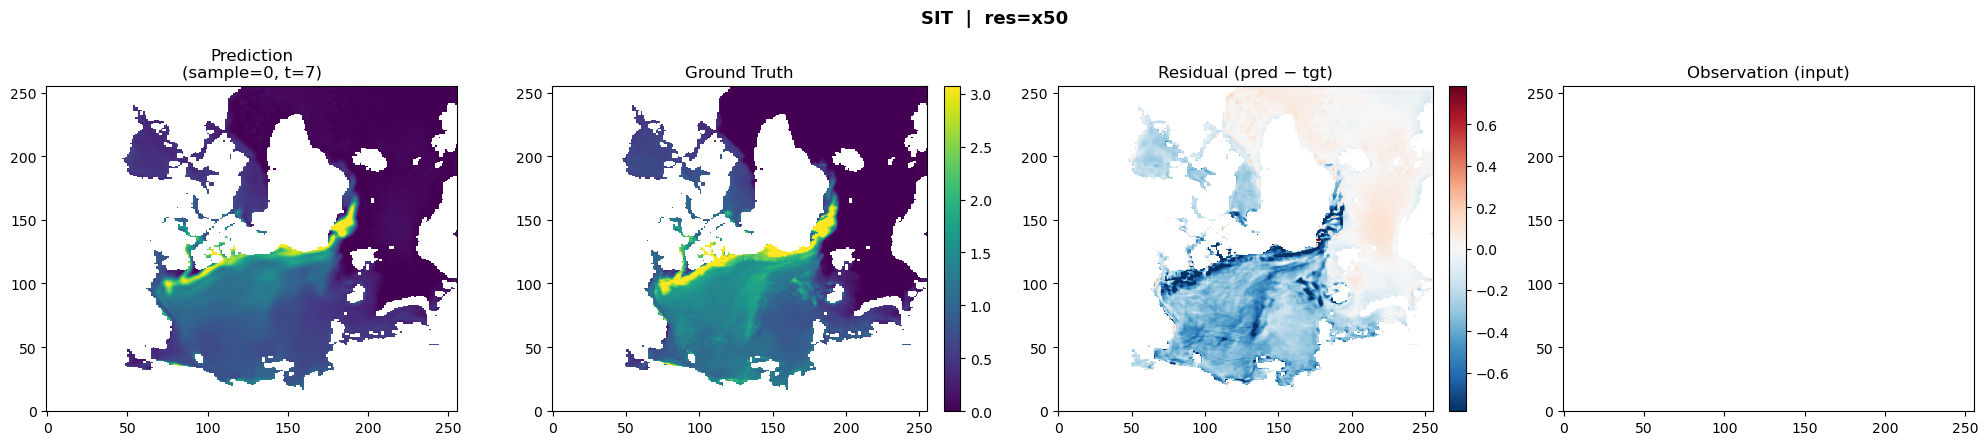

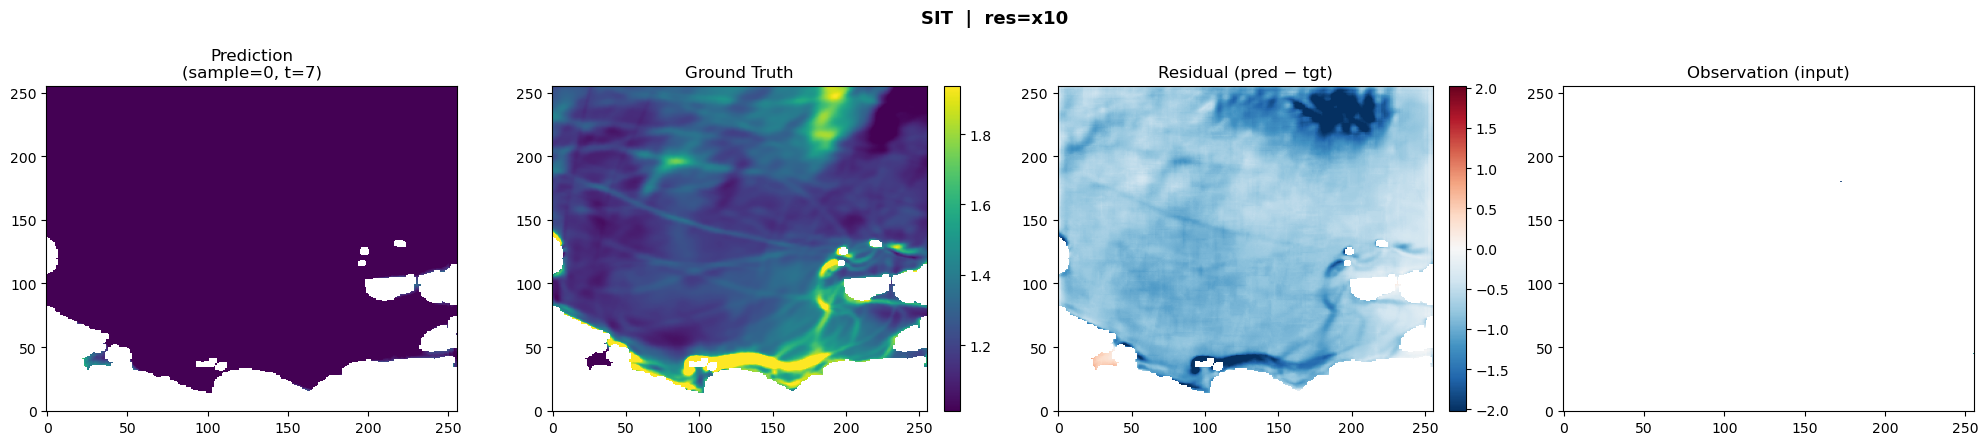

In [22]:
def plot_spatial(var_suffix: str, res: int,
                 sample_idx: int = 0, time_idx: int = 0,
                 unnormalize: bool = True, cmap: str = "viridis"):
    """Side-by-side: Prediction | Ground Truth | Observation | Residual."""
    pred, tgt, obs = concat_results(res, var_suffix, unnormalize=unnormalize)
    n = pred.shape[0]
    sample_idx = min(sample_idx, n - 1)
    time_idx   = min(time_idx,   pred.shape[1] - 1)
    time_idx = 7

    p   = pred[sample_idx, time_idx].copy()
    t   = tgt [sample_idx, time_idx]

    # Apply GT mask to prediction (wherever GT is NaN, mask prediction too)
    gt_mask = np.isnan(t)
    p[gt_mask] = np.nan

    r   = p - t   # residual

    vmin = np.nanpercentile(t, 2)
    vmax = np.nanpercentile(t, 98)

    ncols = 4 if obs is not None else 3
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4.5))

    axes[0].imshow(p, vmin=vmin, vmax=vmax, cmap=cmap, origin="lower", aspect="auto")
    axes[0].set_title(f"Prediction\n(sample={sample_idx}, t={time_idx})")

    im = axes[1].imshow(t, vmin=vmin, vmax=vmax, cmap=cmap, origin="lower", aspect="auto")
    axes[1].set_title(f"Ground Truth")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    rv = np.nanpercentile(np.abs(r), 98)
    rim = axes[2].imshow(r, vmin=-rv, vmax=rv, cmap="RdBu_r", origin="lower", aspect="auto")
    axes[2].set_title("Residual (pred − tgt)")
    plt.colorbar(rim, ax=axes[2], fraction=0.046, pad=0.04)

    if obs is not None:
        o = obs[sample_idx, time_idx]
        axes[3].imshow(o, vmin=vmin, vmax=vmax, cmap=cmap, origin="lower", aspect="auto")
        #axes[3].scatter(np.arange(256),np.arange(256),c=np.reshape(o,(256,256)),vmin=vmin, vmax=vmax, cmap=cmap)
        axes[3].set_title("Observation (input)")

    fig.suptitle(f"{var_suffix}  |  res=x{res}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Static example — all resolutions × variables
for _res in model.multires:
    for _v in model._get_target_vars_for_resolution(_res):
        _suf = _v.split("_", 1)[1] if "_" in _v else _v
        plot_spatial(_suf, _res, sample_idx=0, time_idx=0)


## 8. Error Maps & RMSE Spatial Distribution

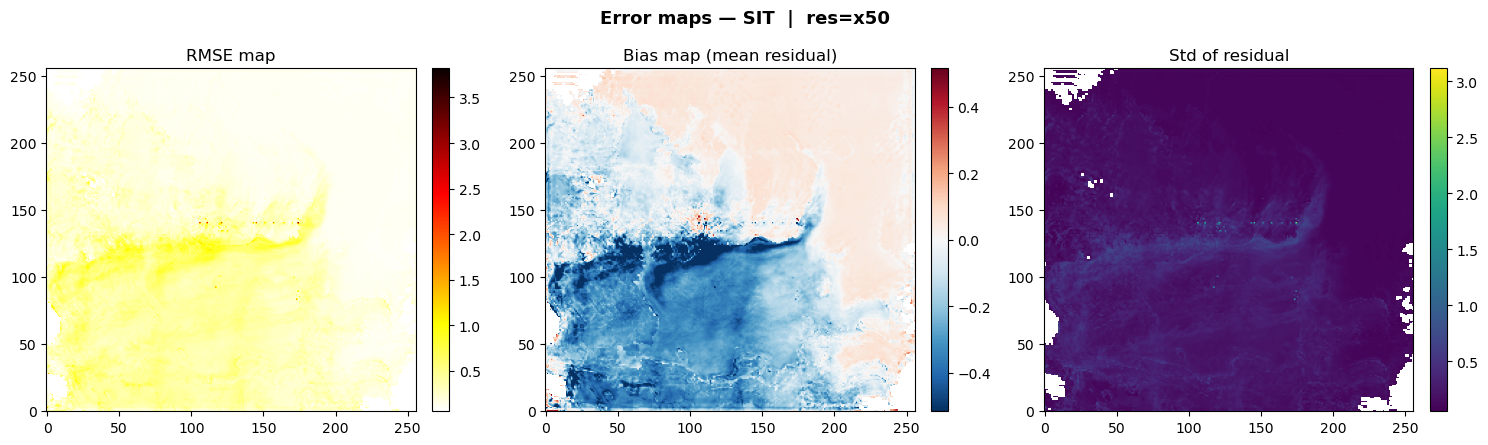

  Global RMSE : 0.2638
  Global bias : -0.1139


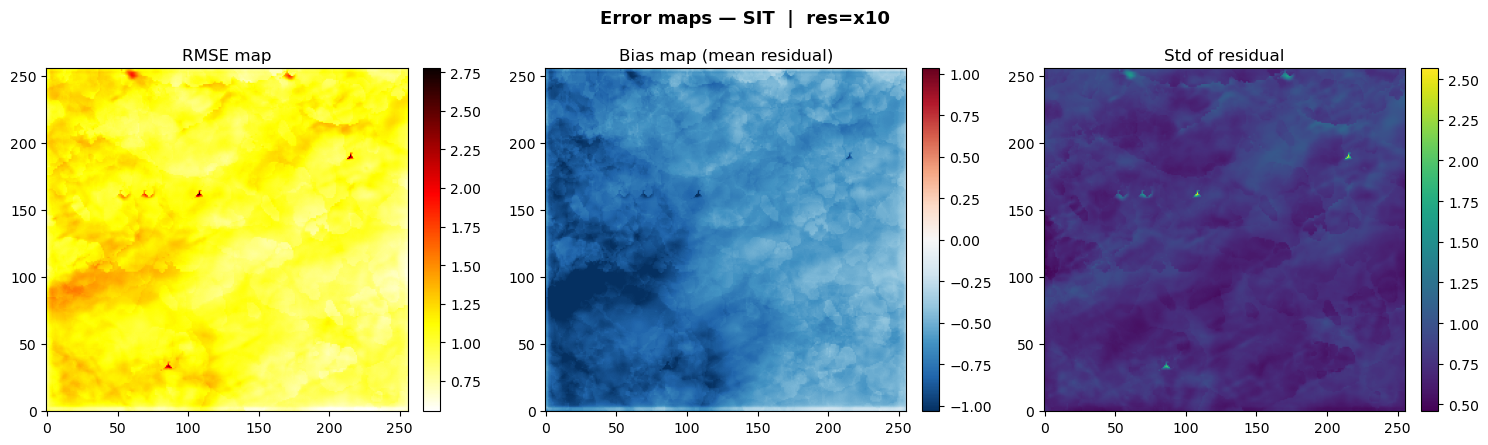

  Global RMSE : 1.0414
  Global bias : -0.6951


In [9]:
def plot_error_maps(var_suffix: str, res: int, unnormalize: bool = True):
    """RMSE map and bias map averaged over all samples and time steps."""
    pred, tgt, _ = concat_results(res, var_suffix, unnormalize=unnormalize)
    residual = pred - tgt                              # (N, T, H, W)
    rmse_map = np.sqrt(np.nanmean(residual ** 2, axis=(0, 1)))   # (H, W)
    bias_map = np.nanmean(residual, axis=(0, 1))                  # (H, W)
    std_map  = np.nanstd(residual,  axis=(0, 1))                  # (H, W)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    im0 = axes[0].imshow(rmse_map, cmap="hot_r", origin="lower", aspect="auto")
    axes[0].set_title("RMSE map")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    rv = np.nanpercentile(np.abs(bias_map), 98)
    im1 = axes[1].imshow(bias_map, vmin=-rv, vmax=rv, cmap="RdBu_r",
                          origin="lower", aspect="auto")
    axes[1].set_title("Bias map (mean residual)")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(std_map, cmap="viridis", origin="lower", aspect="auto")
    axes[2].set_title("Std of residual")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    fig.suptitle(f"Error maps — {var_suffix}  |  res=x{res}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"  Global RMSE : {np.nanmean(rmse_map):.4f}")
    print(f"  Global bias : {np.nanmean(bias_map):.4f}")

# All resolutions × variables
for _res in model.multires:
    for _v in model._get_target_vars_for_resolution(_res):
        _suf = _v.split("_", 1)[1] if "_" in _v else _v
        plot_error_maps(_suf, _res)


## 9. Per-Variable Metrics & Time Series

$$\text{RMSE}(t) = \sqrt{\frac{1}{N}\sum_{i}(\hat{x}_i(t) - x_i(t))^2}, \quad \mu = 1 - \frac{\text{RMSE}}{\sigma_{\text{tgt}}}$$

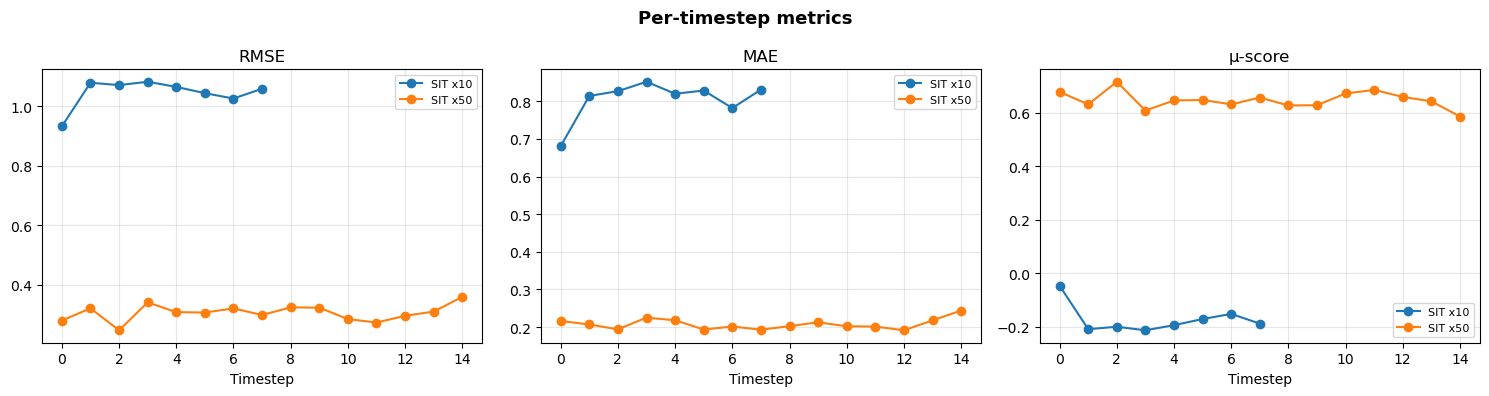


Summary table:


,var,res,mean_RMSE,mean_MAE,mean_mu
0,SIT,10,1.0443,0.8043,-0.1712
1,SIT,50,0.3065,0.2080,0.6482


In [10]:
def compute_metrics(var_suffix: str, res: int, unnormalize: bool = True) -> pd.DataFrame:
    """Return per-timestep RMSE, MAE, and μ-score as a DataFrame."""
    pred, tgt, _ = concat_results(res, var_suffix, unnormalize=unnormalize)
    # pred, tgt: (N, T, H, W)
    T = pred.shape[1]
    records = []
    for t in range(T):
        p_t = pred[:, t].ravel()
        g_t = tgt [:, t].ravel()
        mask = np.isfinite(p_t) & np.isfinite(g_t)
        if mask.sum() == 0:
            records.append({"timestep": t, "RMSE": np.nan, "MAE": np.nan, "mu": np.nan})
            continue
        rmse = np.sqrt(np.mean((p_t[mask] - g_t[mask]) ** 2))
        mae  = np.mean(np.abs(p_t[mask] - g_t[mask]))
        mu   = 1.0 - rmse / (np.std(g_t[mask]) + 1e-8)
        records.append({"timestep": t, "RMSE": rmse, "MAE": mae, "mu": mu})
    return pd.DataFrame(records).set_index("timestep")


def plot_metrics(unnormalize: bool = True):
    """Plot RMSE / MAE / μ per timestep for every variable × resolution."""
    all_vars = set()
    for res in model.multires:
        for v in model._get_target_vars_for_resolution(res):
            all_vars.add((res, v.split("_", 1)[1] if "_" in v else v))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    colors = plt.cm.tab10.colors

    summary_rows = []
    for i, (res, var_suffix) in enumerate(sorted(all_vars)):
        df = compute_metrics(var_suffix, res, unnormalize=unnormalize)
        label = f"{var_suffix} x{res}"
        c = colors[i % len(colors)]
        axes[0].plot(df.index, df["RMSE"], marker="o", color=c, label=label)
        axes[1].plot(df.index, df["MAE"],  marker="o", color=c, label=label)
        axes[2].plot(df.index, df["mu"],   marker="o", color=c, label=label)
        summary_rows.append({
            "var": var_suffix, "res": res,
            "mean_RMSE": df["RMSE"].mean(),
            "mean_MAE":  df["MAE"].mean(),
            "mean_mu":   df["mu"].mean(),
        })

    for ax, title in zip(axes, ["RMSE", "MAE", "μ-score"]):
        ax.set_xlabel("Timestep")
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.suptitle("Per-timestep metrics", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame(summary_rows)
    print("\nSummary table:")
    display(summary.round(4))

plot_metrics(unnormalize=True)

## 10. Interactive Explorer (ipywidgets)

Sélectionner variable, résolution, sample et timestep à la volée.

In [11]:
# Collect all available (res, var_suffix) combos
_all_res_var = []
for _res in model.multires:
    for _v in model._get_target_vars_for_resolution(_res):
        _suf = _v.split("_", 1)[1] if "_" in _v else _v
        _all_res_var.append((_res, _suf))

_res_var_labels = [f"{v} x{r}" for r, v in _all_res_var]

# Determine max samples / timesteps
_n_samples = len(results[model.multires[0]])   # number of batches collected
_n_time    = results[model.multires[0]][0][f"pred_{_all_res_var[0][1]}"].shape[1]

# ── Widgets ───────────────────────────────────────────────────────────
w_rv        = widgets.Dropdown(options=_res_var_labels, description="Var × Res:", layout=widgets.Layout(width="200px"))
w_sample    = widgets.IntSlider(min=0, max=max(_n_samples - 1, 0), value=0, description="Sample:", continuous_update=False)
w_time      = widgets.IntSlider(min=0, max=max(_n_time - 1, 0),   value=0, description="Timestep:", continuous_update=False)
w_unnorm    = widgets.Checkbox(value=True, description="Unnormalise")
w_cmap      = widgets.Dropdown(options=["viridis", "Blues", "RdYlBu_r", "inferno"], value="viridis", description="Colormap:")
w_show_err  = widgets.Checkbox(value=True, description="Error maps")
w_btn       = widgets.Button(description="▶ Refresh", button_style="success")
out         = widgets.Output()

def _refresh(_=None):
    with out:
        clear_output(wait=True)
        idx         = _res_var_labels.index(w_rv.value)
        res, var_s  = _all_res_var[idx]
        s_idx       = w_sample.value
        t_idx       = w_time.value
        unnorm_flag = w_unnorm.value
        cmap        = w_cmap.value

        plot_spatial(var_s, res, sample_idx=s_idx, time_idx=t_idx,
                     unnormalize=unnorm_flag, cmap=cmap)
        if w_show_err.value:
            plot_error_maps(var_s, res, unnormalize=unnorm_flag)
        df = compute_metrics(var_s, res, unnormalize=unnorm_flag)
        print(f"\nMetrics summary for {var_s} x{res}:")
        display(df.describe().round(4))

w_btn.on_click(_refresh)

# Layout
controls = widgets.VBox([
    widgets.HBox([w_rv, w_cmap, w_unnorm, w_show_err]),
    widgets.HBox([w_sample, w_time]),
    w_btn,
])
display(controls, out)
_refresh()   # initial render

Output()

## 11. Ensemble Sampling — N Members & Uncertainty

Pour un batch donné, on lance **N passages forward** du modèle de consistance
(chacun part d'un bruit différent) et on visualise les membres individuels ainsi
que la moyenne et l'écart-type de l'ensemble.


Ensemble: 10 members  |  var=SIT  res=x50  batch=0  sample=0  t=0
  mean range : [-0.137, 7.609]
  std  range : [0.0000,  0.0044]


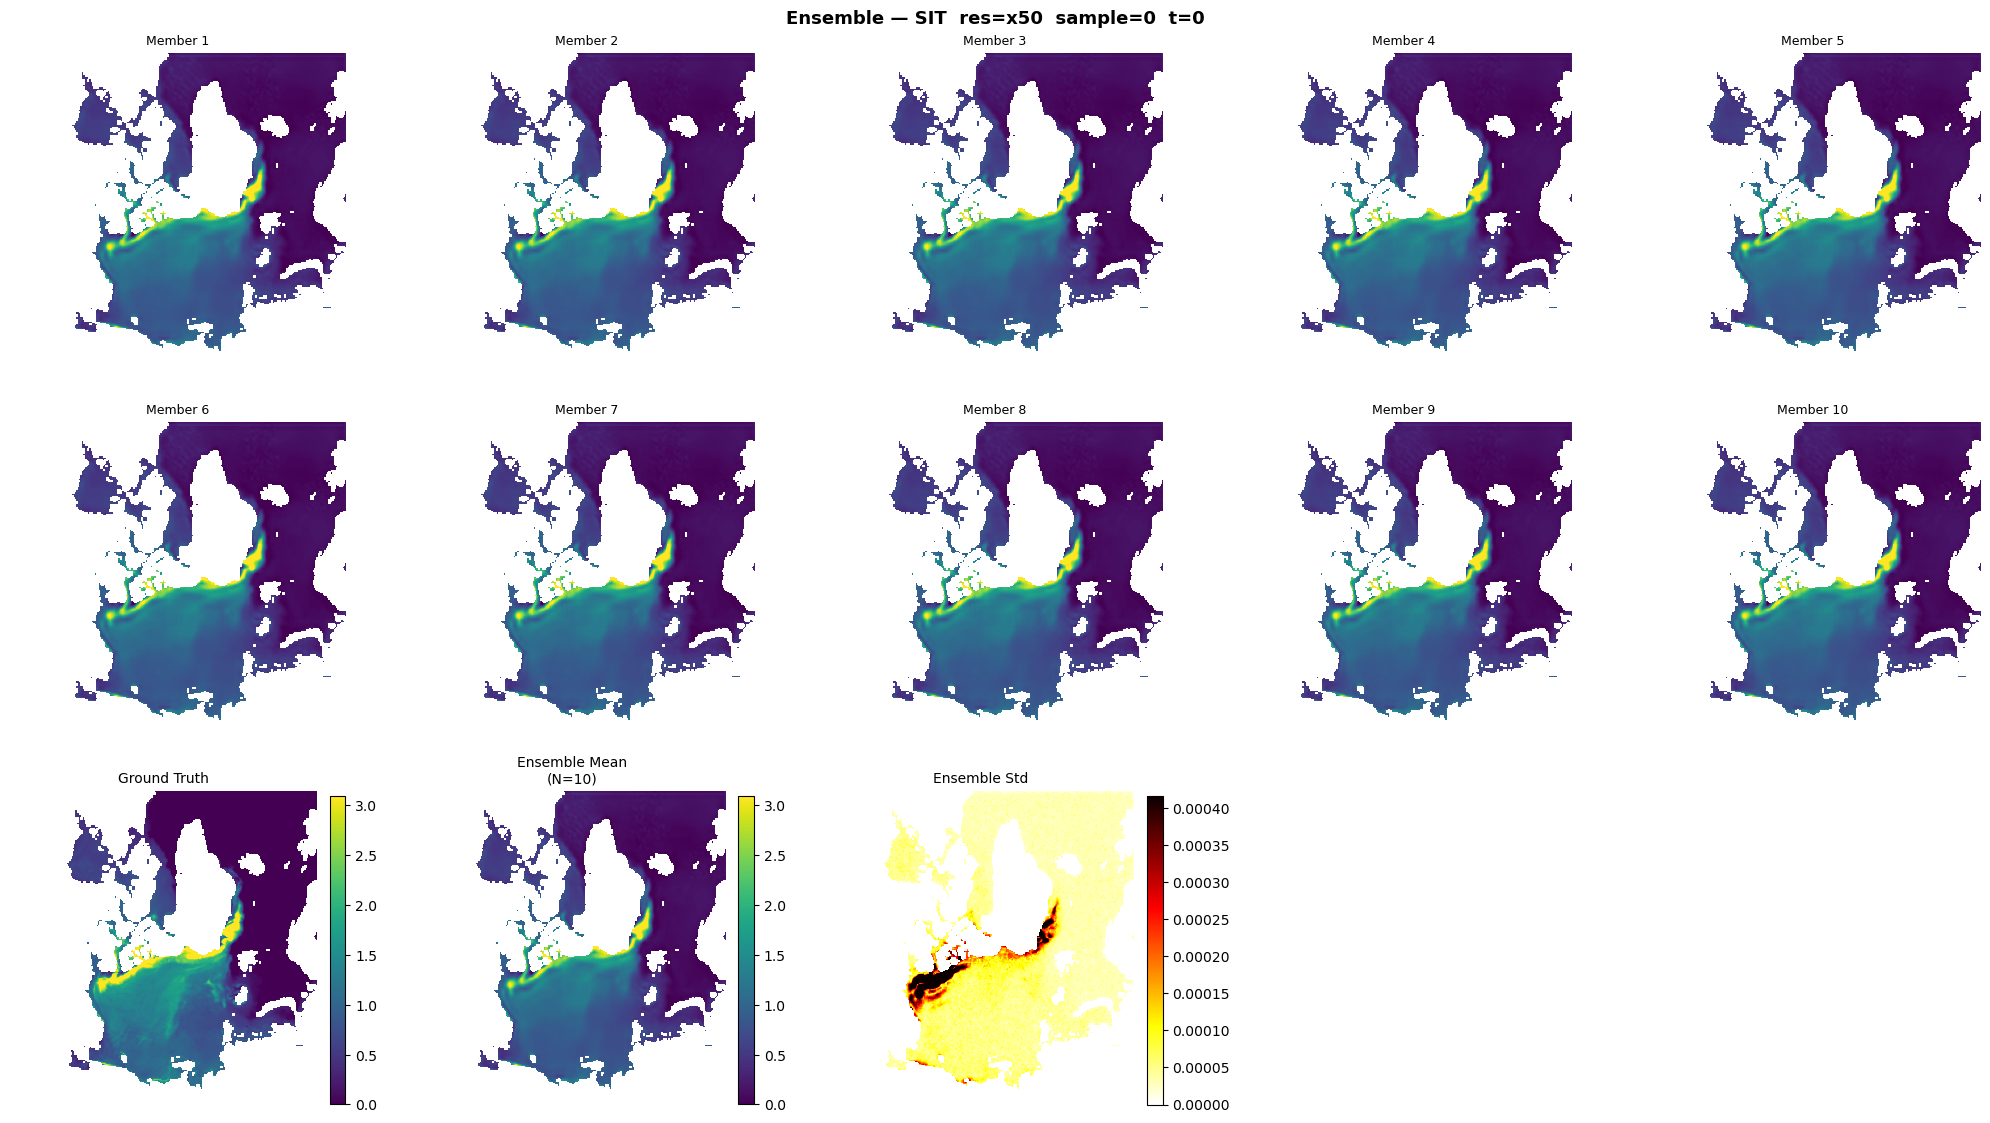

In [12]:

# ── Parameters ────────────────────────────────────────────────────────
ENS_BATCH_IDX = 0       # which batch to use
ENS_SAMPLE    = 0       # which sample within the batch
ENS_TIME      = 0       # which timestep to display
ENS_RES       = model.multires[0]   # resolution
ENS_VAR       = var0                # variable suffix (e.g. 'SIT')
N_MEMBERS     = 10      # number of stochastic forward passes

# ── Extract the batch ─────────────────────────────────────────────────
res_key = f"patch_x{ENS_RES}"
raw_batch = next(
    b for i, b in enumerate(test_dl) if i == ENS_BATCH_IDX
)
b_ens = raw_batch[res_key] if isinstance(raw_batch, dict) else raw_batch
b_ens = model.modify_batch(b_ens, ENS_RES)

stats = get_stats_for_var(ENS_VAR, ENS_RES)

# ── Run N stochastic forward passes ──────────────────────────────────
members = []   # list of (H, W) arrays, one per member
model.eval()
with torch.no_grad():
    for _ in range(N_MEMBERS):
        sbatch = model.format_batch_for_solver(b_ens, include_masks=model.include_masks, res=ENS_RES)
        # Call the solver directly with stochastic=True (reverse-SDE sampling)
        out_t  = model.solver(sbatch, res=ENS_RES, stochastic=False)
        out_d  = model.split_tensor_to_dict(out_t, res=ENS_RES)
        pred_np = out_d[f"pred_{ENS_VAR}"].cpu().float().numpy()   # (B, T, H, W)
        pred_np = unnorm(pred_np, stats)
        members.append(pred_np[ENS_SAMPLE, ENS_TIME])   # (H, W)

members = np.stack(members, axis=0)   # (N_MEMBERS, H, W)

# Ground truth for reference
tgt_np = getattr(b_ens, f"models_{ENS_VAR}").cpu().float().numpy()
tgt_np = unnorm(tgt_np, stats)
tgt_slice = tgt_np[ENS_SAMPLE, ENS_TIME]   # (H, W)

# Apply GT land mask
land_mask = np.isnan(tgt_slice)
for m in range(N_MEMBERS):
    members[m][land_mask] = np.nan

ens_mean = np.nanmean(members, axis=0)   # (H, W)
ens_std  = np.nanstd(members,  axis=0)   # (H, W)

print(f"Ensemble: {N_MEMBERS} members  |  var={ENS_VAR}  res=x{ENS_RES}  "
      f"batch={ENS_BATCH_IDX}  sample={ENS_SAMPLE}  t={ENS_TIME}")
print(f"  mean range : [{np.nanmin(ens_mean):.3f}, {np.nanmax(ens_mean):.3f}]")
print(f"  std  range : [{np.nanmin(ens_std):.4f},  {np.nanmax(ens_std):.4f}]")

# ── Plot members + mean + std + GT ───────────────────────────────────
vmin = np.nanpercentile(tgt_slice, 2)
vmax = np.nanpercentile(tgt_slice, 98)

n_cols  = min(N_MEMBERS, 5)
n_rows_members = int(np.ceil(N_MEMBERS / n_cols))
total_rows = n_rows_members + 1   # extra row for mean / std / GT

fig, axes = plt.subplots(total_rows, n_cols,
                          figsize=(4 * n_cols, 3.8 * total_rows))
axes = np.array(axes).reshape(total_rows, n_cols)

# Member panels
for i in range(N_MEMBERS):
    r, c = divmod(i, n_cols)
    axes[r, c].imshow(members[i], vmin=vmin, vmax=vmax,
                      cmap="viridis", origin="lower", aspect="auto")
    axes[r, c].set_title(f"Member {i+1}", fontsize=9)
    axes[r, c].axis("off")

# Hide unused member slots in last members row
for j in range(N_MEMBERS % n_cols or n_cols, n_cols):
    axes[n_rows_members - 1, j].axis("off")

# Bottom row: GT | Ensemble mean | Ensemble std
ax_gt   = axes[n_rows_members, 0]
ax_mean = axes[n_rows_members, 1]
ax_std  = axes[n_rows_members, 2]

im_gt = ax_gt.imshow(tgt_slice, vmin=vmin, vmax=vmax,
                     cmap="viridis", origin="lower", aspect="auto")
ax_gt.set_title("Ground Truth", fontsize=10)
ax_gt.axis("off")
plt.colorbar(im_gt, ax=ax_gt, fraction=0.046, pad=0.04)

im_m = ax_mean.imshow(ens_mean, vmin=vmin, vmax=vmax,
                      cmap="viridis", origin="lower", aspect="auto")
ax_mean.set_title(f"Ensemble Mean\n(N={N_MEMBERS})", fontsize=10)
ax_mean.axis("off")
plt.colorbar(im_m, ax=ax_mean, fraction=0.046, pad=0.04)

sv = np.nanpercentile(ens_std, 98)
im_s = ax_std.imshow(ens_std, vmin=0, vmax=sv,
                     cmap="hot_r", origin="lower", aspect="auto")
ax_std.set_title("Ensemble Std", fontsize=10)
ax_std.axis("off")
plt.colorbar(im_s, ax=ax_std, fraction=0.046, pad=0.04)

# Hide remaining bottom slots
for j in range(3, n_cols):
    axes[n_rows_members, j].axis("off")

fig.suptitle(f"Ensemble — {ENS_VAR}  res=x{ENS_RES}  "
             f"sample={ENS_SAMPLE}  t={ENS_TIME}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
